# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Agora pode importar o config
from notebooks.config import config

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterSpectralModule as cluster
import Modules.FutureAnalysisModule as fa

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = config["datapath"]
COVID_TRAIN_DATA_FILE = config["covid_train_data_file"]
COVID_TEST_DATA_FILE = config["covid_test_data_file"]
FUTURE_DATA_FILE = config["future_data_file"]

FIGSIZE_CLUSTER_HEATMAP = config["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = config["figsize_future_heatmap"]
IMAGES_SAVE_PATH = config["image_save_path"]

TRIALS_OPTUNA = 250

# Import data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [3]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [4]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [5]:
featuresNotConsidered = ['died', 'died_in_stay', 'died_after', 'COVID', 'subject_id', 'hadm_id']

In [6]:
helper = cluster.SpectralClusterHelper(data=data_covid, featuresNotConsidered=featuresNotConsidered)

## Find best hyperparameters for spectral clustering

### PCA

In [7]:
param = {
    "affinity": ["rbf", "nearest_neighbors"],
    "gamma": {"min": 1e-4, "max": 1e-2},
    "n_neighbors": {"min": 1, "max": 100},
    "n_clusters": {"min": 2, "max": 5},
}

In [8]:
os.environ['PYTHONWARNINGS'] = 'ignore'
pca_disco_df, pca_disco_param, pca_disco_best = helper.optunaGridSearch(
    suffix="pca",
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="disco",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80,
    dimensionality_reduction={"method": "PCA", "dimensions": 30}
)

[I 2026-01-17 20:38:54,979] A new study created in RDB with name: Optuna Study Spectral Clustering Pca DISCO 0
[I 2026-01-17 20:38:55,798] Trial 0 finished with value: -3.0 and parameters: {'affinity': 'rbf', 'gamma': 0.0020673111792281914, 'n_clusters': 2}. Best is trial 0 with value: -3.0.
[I 2026-01-17 20:38:56,693] Trial 1 finished with value: -3.0 and parameters: {'affinity': 'rbf', 'gamma': 0.0018188925728721925, 'n_clusters': 3}. Best is trial 0 with value: -3.0.
[I 2026-01-17 20:39:00,549] Trial 2 finished with value: -0.2397760580594332 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 83, 'n_clusters': 5}. Best is trial 2 with value: -0.2397760580594332.
[I 2026-01-17 20:39:04,747] Trial 3 finished with value: -0.211196742104868 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 43, 'n_clusters': 5}. Best is trial 3 with value: -0.211196742104868.
[I 2026-01-17 20:39:06,348] Trial 4 finished with value: -0.09530821317153516 and parameters: {'affin


Best parameters: {'affinity': 'rbf', 'gamma': 0.0009106078339493842, 'n_clusters': 2}
Best DISCO score: 0.2178400155749344



In [9]:
os.environ['PYTHONWARNINGS'] = 'ignore'
pca_dbcv_df, pca_dbcv_param, pca_dbcv_best = helper.optunaGridSearch(
    suffix="pca",
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dbcv",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80,
    dimensionality_reduction={"method": "PCA", "dimensions": 30}
)

[I 2026-01-17 20:45:53,551] A new study created in RDB with name: Optuna Study Spectral Clustering Pca DBCV 0
[I 2026-01-17 20:45:57,758] Trial 0 finished with value: -0.9793851817754164 and parameters: {'affinity': 'rbf', 'gamma': 0.0003023241772363317, 'n_clusters': 5}. Best is trial 0 with value: -0.9793851817754164.
[I 2026-01-17 20:46:03,468] Trial 1 finished with value: -0.9949255886488984 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 100, 'n_clusters': 3}. Best is trial 0 with value: -0.9793851817754164.
[I 2026-01-17 20:46:09,035] Trial 2 finished with value: -0.9784175897447872 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 83, 'n_clusters': 2}. Best is trial 2 with value: -0.9784175897447872.
[I 2026-01-17 20:46:14,847] Trial 3 finished with value: -0.9733267964674479 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 18, 'n_clusters': 4}. Best is trial 3 with value: -0.9733267964674479.
[I 2026-01-17 20:46:18,741] Trial 4 fi


Best parameters: {'affinity': 'rbf', 'gamma': 0.00025242391478721293, 'n_clusters': 4}
Best DBCV score: -0.870855942903172



In [10]:
os.environ['PYTHONWARNINGS'] = 'ignore'
pca_dsi_df, pca_dsi_param, pca_dsi_best = helper.optunaGridSearch(
    suffix="pca",
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dsi",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80,
    dimensionality_reduction={"method": "PCA", "dimensions": 30}
)

[I 2026-01-17 21:07:13,647] A new study created in RDB with name: Optuna Study Spectral Clustering Pca DSI 0
[I 2026-01-17 21:07:15,536] Trial 0 finished with value: 0.167 and parameters: {'affinity': 'rbf', 'gamma': 0.00026730403697877323, 'n_clusters': 2}. Best is trial 0 with value: 0.167.
[I 2026-01-17 21:07:17,669] Trial 1 finished with value: 0.138 and parameters: {'affinity': 'rbf', 'gamma': 0.00023225664630936594, 'n_clusters': 4}. Best is trial 0 with value: 0.167.
[I 2026-01-17 21:07:18,356] Trial 2 finished with value: -3.0 and parameters: {'affinity': 'rbf', 'gamma': 0.0019218771509462388, 'n_clusters': 2}. Best is trial 0 with value: 0.167.
[I 2026-01-17 21:07:22,616] Trial 3 finished with value: 0.095 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 95, 'n_clusters': 2}. Best is trial 0 with value: 0.167.
[I 2026-01-17 21:07:26,773] Trial 4 finished with value: 0.078 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 20, 'n_clusters': 5}. Bes


Best parameters: {'affinity': 'rbf', 'gamma': 0.0008651840423885792, 'n_clusters': 3}
Best DSI score: 0.26



In [11]:
os.environ['PYTHONWARNINGS'] = 'ignore'
pca_silhouette_df, pca_silhouette_param, pca_silhouette_best = helper.optunaGridSearch(
    suffix="pca",
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="silhouette",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80,
    dimensionality_reduction={"method": "PCA", "dimensions": 30}
)

[I 2026-01-17 21:13:49,894] A new study created in RDB with name: Optuna Study Spectral Clustering Pca SILHOUETTE 0
[I 2026-01-17 21:13:53,246] Trial 0 finished with value: 0.096 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 96, 'n_clusters': 2}. Best is trial 0 with value: 0.096.
[I 2026-01-17 21:13:54,489] Trial 1 finished with value: -0.022 and parameters: {'affinity': 'rbf', 'gamma': 0.0005524597057972736, 'n_clusters': 4}. Best is trial 0 with value: 0.096.
[I 2026-01-17 21:13:55,384] Trial 2 finished with value: -3.0 and parameters: {'affinity': 'rbf', 'gamma': 0.005579893559443769, 'n_clusters': 5}. Best is trial 0 with value: 0.096.
[I 2026-01-17 21:13:56,345] Trial 3 finished with value: 0.12 and parameters: {'affinity': 'rbf', 'gamma': 0.0006652862575949512, 'n_clusters': 3}. Best is trial 3 with value: 0.12.
[I 2026-01-17 21:13:57,169] Trial 4 finished with value: -3.0 and parameters: {'affinity': 'rbf', 'gamma': 0.002004283815185055, 'n_clusters': 3}. Bes


Best parameters: {'affinity': 'rbf', 'gamma': 0.0009398578976193796, 'n_clusters': 2}
Best SILHOUETTE score: 0.218



In [12]:
helper.clustering(
    n_clusters=pca_disco_param["n_clusters"],
    affinity=pca_disco_param["affinity"],
    n_neighbors=pca_disco_param.get("n_neighbors", 10),
    gamma=pca_disco_param.get("gamma", 1e-3),
    dimensionality_reduction={"method": "PCA", "dimensions": 30},
)
helper.getMetrics()

{'silhouette': 0.217,
 'dbcv': -0.9832309394701447,
 'dsi': np.float64(0.162),
 'disco': np.float64(0.2178400155749344)}

In [13]:
helper.clustering(
    n_clusters=pca_dbcv_param["n_clusters"],
    affinity=pca_dbcv_param["affinity"],
    n_neighbors=pca_dbcv_param.get("n_neighbors", 10),
    gamma=pca_dbcv_param.get("gamma", 1e-3),
    dimensionality_reduction={"method": "PCA", "dimensions": 30},
)
helper.getMetrics()

{'silhouette': -0.073,
 'dbcv': -0.870855942903172,
 'dsi': np.float64(0.088),
 'disco': np.float64(-0.10554294079049162)}

In [14]:
helper.clustering(
    n_clusters=pca_dsi_param["n_clusters"],
    affinity=pca_dsi_param["affinity"],
    n_neighbors=pca_dsi_param.get("n_neighbors", 10),
    gamma=pca_dsi_param.get("gamma", 1e-3),
    dimensionality_reduction={"method": "PCA", "dimensions": 30},
)
helper.getMetrics()

{'silhouette': 0.175,
 'dbcv': -0.9852774116505305,
 'dsi': np.float64(0.26),
 'disco': np.float64(0.1620445648790673)}

In [15]:
helper.clustering(
    n_clusters=pca_silhouette_param["n_clusters"],
    affinity=pca_silhouette_param["affinity"],
    n_neighbors=pca_silhouette_param.get("n_neighbors", 10),
    gamma=pca_silhouette_param.get("gamma", 1e-3),
    dimensionality_reduction={"method": "PCA", "dimensions": 30},
)
helper.getMetrics()

{'silhouette': 0.218,
 'dbcv': -0.9832090229139073,
 'dsi': np.float64(0.162),
 'disco': np.float64(0.21914700777922735)}

### Autoencoder

In [16]:
os.environ['PYTHONWARNINGS'] = 'ignore'
ae_disco_df, ae_disco_param, ae_disco_best = helper.optunaGridSearch(
    suffix="ae",
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="disco",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80,
    dimensionality_reduction={"method": "AE", "dimensions": 10}
)

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:26<00:00,  3.78it/s]


[I 2026-01-17 21:19:08,301] A new study created in RDB with name: Optuna Study Spectral Clustering Ae DISCO 0
[I 2026-01-17 21:19:09,605] Trial 0 finished with value: -0.17508144871569614 and parameters: {'affinity': 'rbf', 'gamma': 0.00047695282494306947, 'n_clusters': 5}. Best is trial 0 with value: -0.17508144871569614.
[I 2026-01-17 21:19:11,158] Trial 1 finished with value: 0.12188952811806152 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 26, 'n_clusters': 3}. Best is trial 1 with value: 0.12188952811806152.
[I 2026-01-17 21:19:12,490] Trial 2 finished with value: -0.02003373496748274 and parameters: {'affinity': 'rbf', 'gamma': 0.0017594248615908116, 'n_clusters': 3}. Best is trial 1 with value: 0.12188952811806152.
[I 2026-01-17 21:19:13,678] Trial 3 finished with value: 0.12236560388684316 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 8, 'n_clusters': 3}. Best is trial 3 with value: 0.12236560388684316.
[I 2026-01-17 21:19:13,878] Trial 4 f


Best parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 7, 'n_clusters': 2}
Best DISCO score: 0.46909464097821285



In [17]:
os.environ['PYTHONWARNINGS'] = 'ignore'
ae_dbcv_df, ae_dbcv_param, ae_dbcv_best = helper.optunaGridSearch(
    suffix="ae",
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dbcv",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80,
    dimensionality_reduction={"method": "AE", "dimensions": 10}
)

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:28<00:00,  3.46it/s]


[I 2026-01-17 21:24:05,651] A new study created in RDB with name: Optuna Study Spectral Clustering Ae DBCV 0
[I 2026-01-17 21:24:09,856] Trial 0 finished with value: -0.9776357984577747 and parameters: {'affinity': 'rbf', 'gamma': 0.0002940590795057877, 'n_clusters': 2}. Best is trial 0 with value: -0.9776357984577747.
[I 2026-01-17 21:24:13,894] Trial 1 finished with value: -0.9797648912498615 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 17, 'n_clusters': 3}. Best is trial 0 with value: -0.9776357984577747.
[I 2026-01-17 21:24:18,567] Trial 2 finished with value: -0.993965726702546 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 92, 'n_clusters': 2}. Best is trial 0 with value: -0.9776357984577747.
[I 2026-01-17 21:24:22,661] Trial 3 finished with value: -0.9868561036339308 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 58, 'n_clusters': 5}. Best is trial 0 with value: -0.9776357984577747.
[I 2026-01-17 21:24:26,135] Trial 4 finis


Best parameters: {'affinity': 'rbf', 'gamma': 0.00798087308768162, 'n_clusters': 2}
Best DBCV score: -0.9775960019947015



In [18]:
os.environ['PYTHONWARNINGS'] = 'ignore'
ae_dsi_df, ae_dsi_param, ae_dsi_best = helper.optunaGridSearch(
    suffix="ae",
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dsi",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80,
    dimensionality_reduction={"method": "AE", "dimensions": 10}
)

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:30<00:00,  3.27it/s]


[I 2026-01-17 21:40:51,811] A new study created in RDB with name: Optuna Study Spectral Clustering Ae DSI 0
[I 2026-01-17 21:40:54,268] Trial 0 finished with value: 0.151 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 62, 'n_clusters': 3}. Best is trial 0 with value: 0.151.
[I 2026-01-17 21:40:56,862] Trial 1 finished with value: 0.126 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 78, 'n_clusters': 4}. Best is trial 0 with value: 0.151.
[I 2026-01-17 21:40:58,670] Trial 2 finished with value: 0.108 and parameters: {'affinity': 'rbf', 'gamma': 0.0031162520672063936, 'n_clusters': 5}. Best is trial 0 with value: 0.151.
[I 2026-01-17 21:41:00,426] Trial 3 finished with value: 0.098 and parameters: {'affinity': 'rbf', 'gamma': 0.0015279830921348196, 'n_clusters': 4}. Best is trial 0 with value: 0.151.
[I 2026-01-17 21:41:01,986] Trial 4 finished with value: 0.194 and parameters: {'affinity': 'rbf', 'gamma': 0.0004777851300108683, 'n_clusters': 2}. Best 


Best parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 3, 'n_clusters': 5}
Best DSI score: 0.262



In [19]:
os.environ['PYTHONWARNINGS'] = 'ignore'
ae_silhouette_df, ae_silhouette_param, ae_silhouette_best = helper.optunaGridSearch(
    suffix="ae",
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="silhouette",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80,
    dimensionality_reduction={"method": "AE", "dimensions": 10}
)

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:29<00:00,  3.40it/s]


[I 2026-01-17 21:46:57,882] A new study created in RDB with name: Optuna Study Spectral Clustering Ae SILHOUETTE 0
[I 2026-01-17 21:46:58,698] Trial 0 finished with value: -0.151 and parameters: {'affinity': 'rbf', 'gamma': 0.00039890308423000035, 'n_clusters': 5}. Best is trial 0 with value: -0.151.
[I 2026-01-17 21:46:59,496] Trial 1 finished with value: 0.028 and parameters: {'affinity': 'rbf', 'gamma': 0.002553303240615423, 'n_clusters': 3}. Best is trial 1 with value: 0.028.
[I 2026-01-17 21:47:00,287] Trial 2 finished with value: 0.025 and parameters: {'affinity': 'rbf', 'gamma': 0.004722582868232316, 'n_clusters': 3}. Best is trial 1 with value: 0.028.
[I 2026-01-17 21:47:01,492] Trial 3 finished with value: -0.168 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 16, 'n_clusters': 5}. Best is trial 1 with value: 0.028.
[I 2026-01-17 21:47:02,264] Trial 4 finished with value: -0.085 and parameters: {'affinity': 'rbf', 'gamma': 0.003506923152979129, 'n_clusters': 4


Best parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 7, 'n_clusters': 2}
Best SILHOUETTE score: 0.41



In [20]:
helper.clustering(
    n_clusters=ae_disco_param["n_clusters"],
    affinity=ae_disco_param["affinity"],
    n_neighbors=ae_disco_param.get("n_neighbors", 10),
    gamma=ae_disco_param.get("gamma", 1e-3),
    dimensionality_reduction={"method": "AE", "dimensions": 10},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:28<00:00,  3.52it/s]


{'silhouette': 0.41,
 'dbcv': -0.9888146948167854,
 'dsi': np.float64(0.219),
 'disco': np.float64(0.46909464097821285)}

In [21]:
helper.clustering(
    n_clusters=ae_dbcv_param["n_clusters"],
    affinity=ae_dbcv_param["affinity"],
    n_neighbors=ae_dbcv_param.get("n_neighbors", 10),
    gamma=ae_dbcv_param.get("gamma", 1e-3),
    dimensionality_reduction={"method": "AE", "dimensions": 10},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:27<00:00,  3.60it/s]


{'silhouette': 0.363,
 'dbcv': -0.9775960019947015,
 'dsi': np.float64(0.193),
 'disco': np.float64(0.43722681283242354)}

In [22]:
helper.clustering(
    n_clusters=ae_dsi_param["n_clusters"],
    affinity=ae_dsi_param["affinity"],
    n_neighbors=ae_dsi_param.get("n_neighbors", 10),
    gamma=ae_dsi_param.get("gamma", 1e-3),
    dimensionality_reduction={"method": "AE", "dimensions": 10},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:31<00:00,  3.15it/s]


{'silhouette': -0.164,
 'dbcv': 0.9999729600168098,
 'dsi': np.float64(0.406),
 'disco': np.float64(-0.34675221934516876)}

In [23]:
helper.clustering(
    n_clusters=ae_silhouette_param["n_clusters"],
    affinity=ae_silhouette_param["affinity"],
    n_neighbors=ae_silhouette_param.get("n_neighbors", 10),
    gamma=ae_silhouette_param.get("gamma", 1e-3),
    dimensionality_reduction={"method": "AE", "dimensions": 10},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:30<00:00,  3.28it/s]


{'silhouette': 0.41,
 'dbcv': -0.9888146948167854,
 'dsi': np.float64(0.219),
 'disco': np.float64(0.46909464097821285)}

## PCA

In [45]:
pca_best_param = pca_silhouette_param
pca_best_param

{'affinity': 'rbf', 'gamma': 0.0009398578976193796, 'n_clusters': 2}

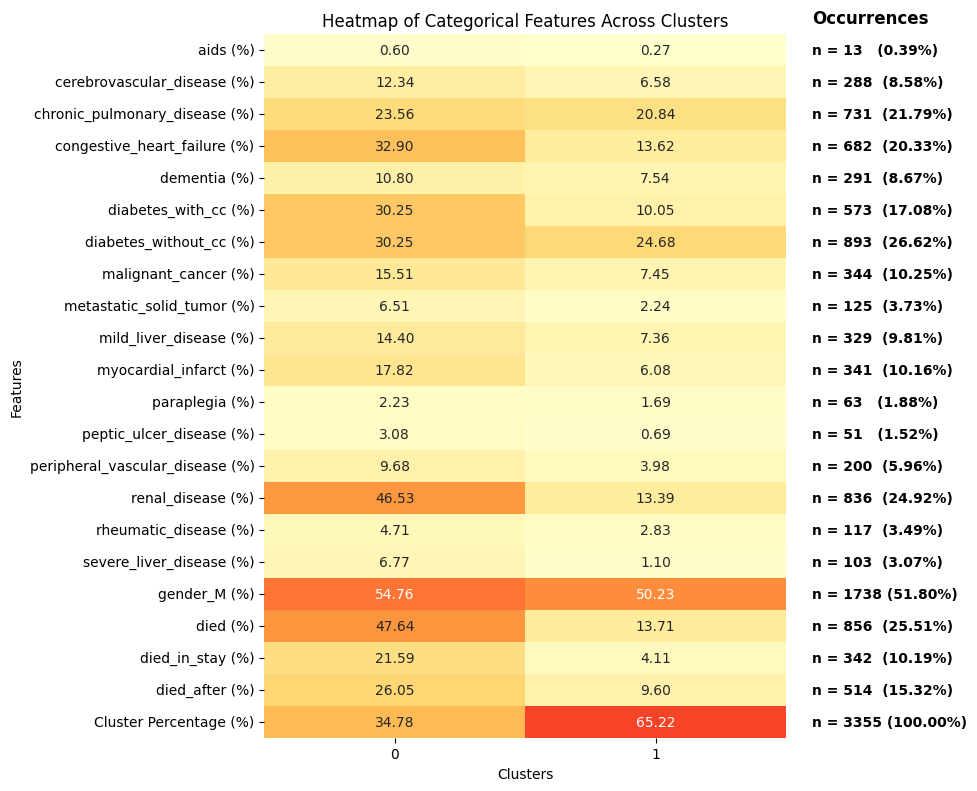

In [46]:
helper.clustering(
    n_clusters=pca_best_param["n_clusters"],
    affinity=pca_best_param["affinity"],
    n_neighbors=pca_best_param.get("n_neighbors", 10),
    gamma=pca_best_param.get("gamma", 1e-3),
    dimensionality_reduction={"method": "PCA", "dimensions": 30},
)
helper.heatmapClustersCategorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    minimumClusterSize=2,
    savepath=IMAGES_SAVE_PATH + "spectral-dr-pca-categorical",
)

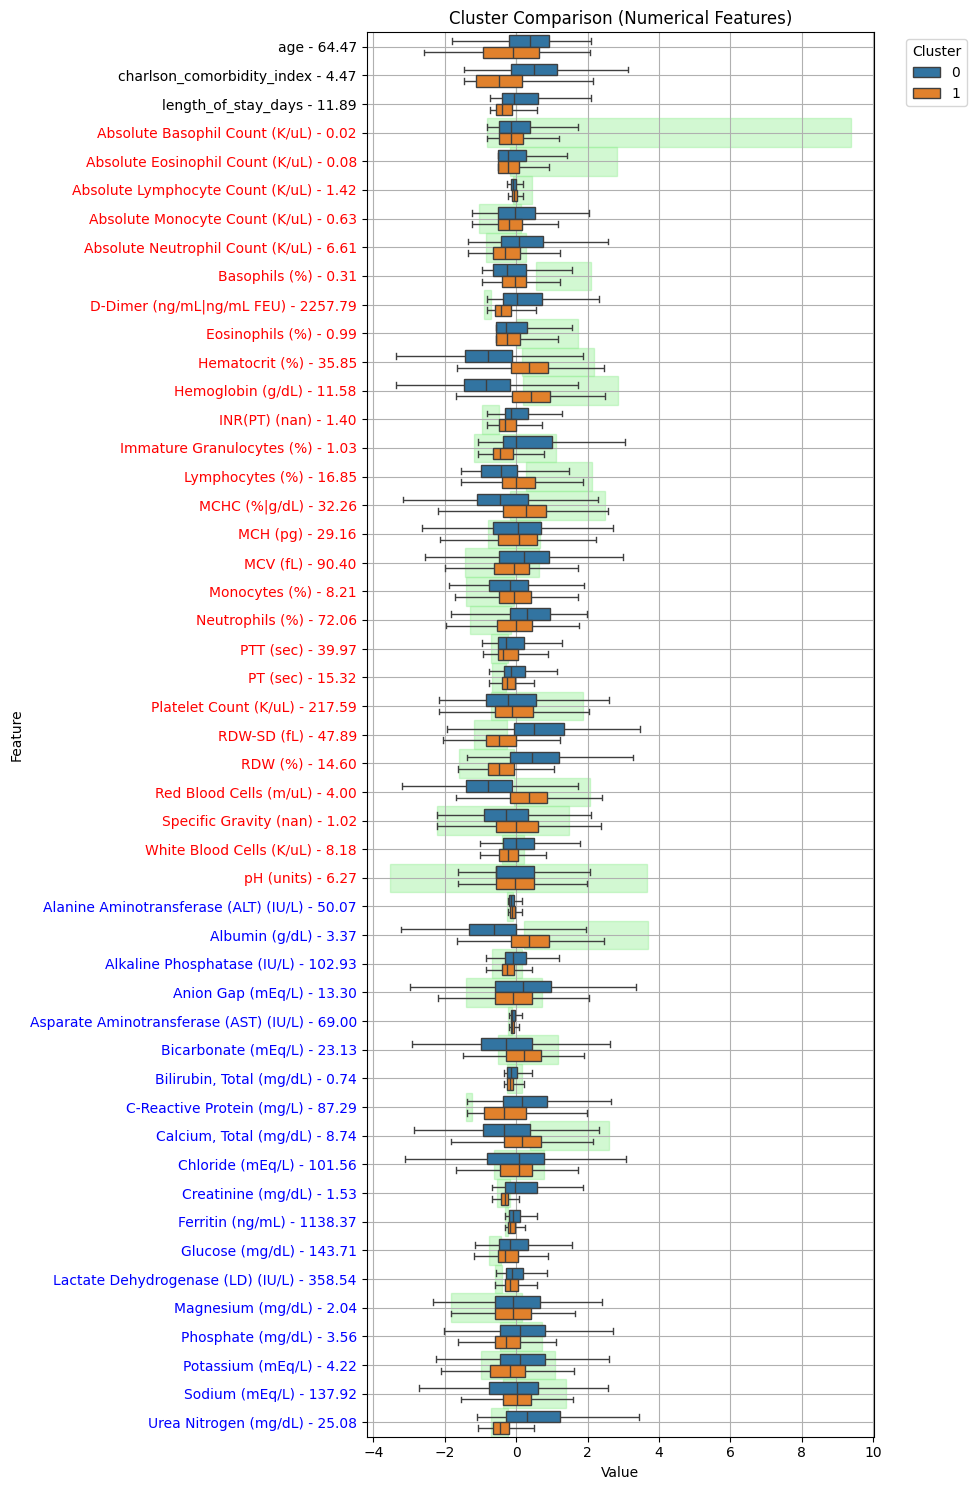

[]

In [47]:
helper.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=-1,
    figsize=(10, 15),
    byVariance=False,
    savepath=IMAGES_SAVE_PATH + "spectral-dr-pca-numerical",
    verbose=1,
)

In [48]:
selectedClusters = [0, 1]

In [49]:
helper.setClusteredAutoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 100%|██████████| 100/100 [00:27<00:00,  3.62it/s]


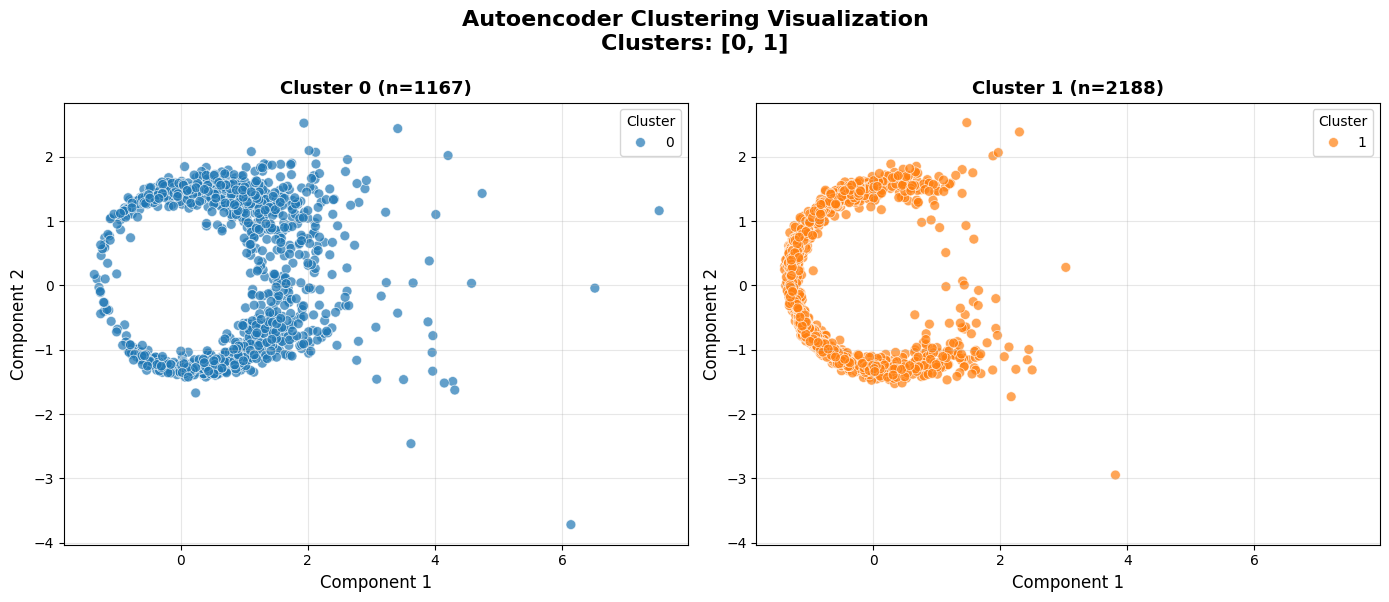

In [50]:
helper.showClusteredAutoencoder(selectedClusters=selectedClusters, savepath=IMAGES_SAVE_PATH + "spectral-autoencoder-dr-pca")

##### Future Data

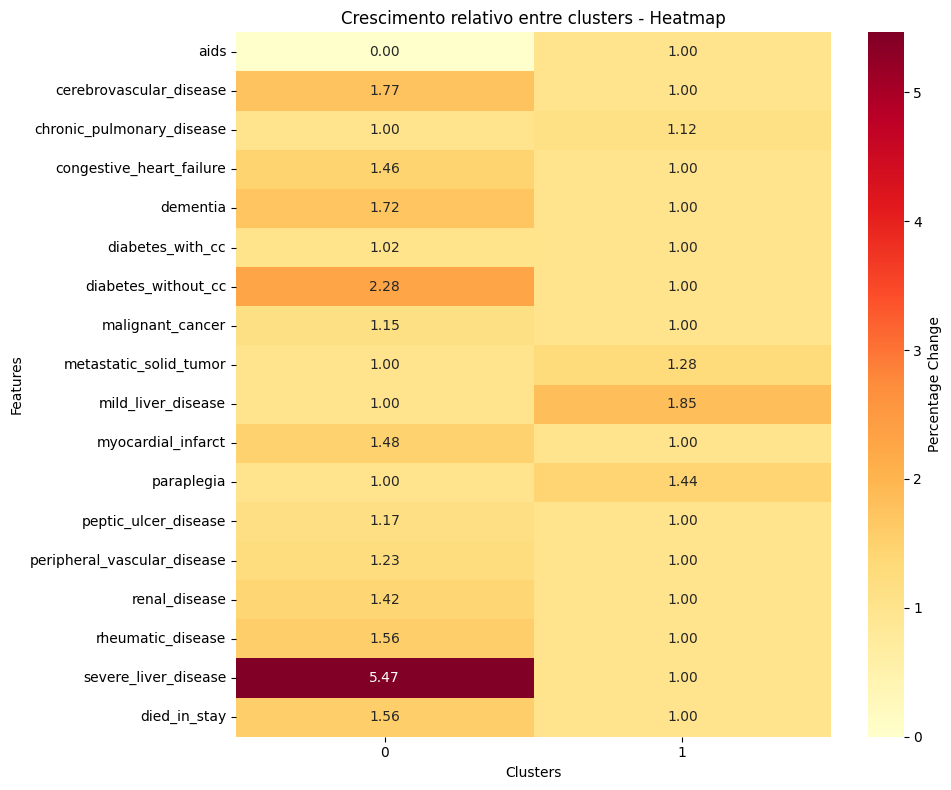

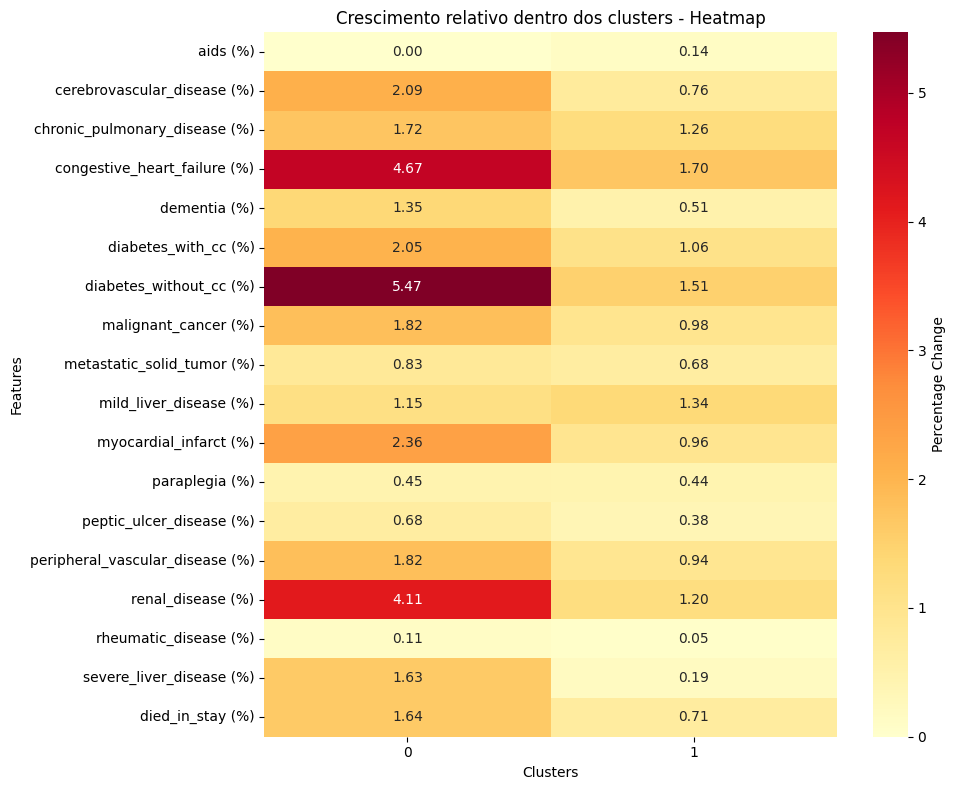

In [51]:
future_helper = fa.FutureAnalysisHelper(helper.clusteredData, future_data)
future_helper.insertClustersInFutureData(onlyFirstAdmission=True)
delta = future_helper.getDeltaClusters(percentage=True, metric="externo")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    selectedClusters=selectedClusters,
    savepath=IMAGES_SAVE_PATH + "spectral-dr-pca-externo",
    metric="externo"
)
delta = future_helper.getDeltaClusters(percentage=True, metric="interno")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    selectedClusters=selectedClusters,
    savepath=IMAGES_SAVE_PATH + "spectral-dr-pca-interno",
    metric="interno"
)

In [36]:
future_helper.getMeanReadmission()

{'Mean readmission Cluster 0': 2.62,
 'Mean readmission Cluster 1': 2.12,
 'Overall Mean readmission': 2.31}

In [37]:
future_helper.getMeanDaysGap()

{'Mean days gap Cluster 0': 118.38,
 'Mean days gap Cluster 1': 133.31,
 'Overall Mean days gap': 127.49}

In [38]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

{'Mortality rate Cluster 0': 0.06,
 'Mortality rate Cluster 1': 0.17,
 'Overall Mortality rate': 0.09}

### Add Log

In [39]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"Spectral, PCA, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")

## Autoencoder

In [52]:
ae_best_param = ae_silhouette_param
ae_best_param

{'affinity': 'nearest_neighbors', 'n_neighbors': 7, 'n_clusters': 2}

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:30<00:00,  3.32it/s]


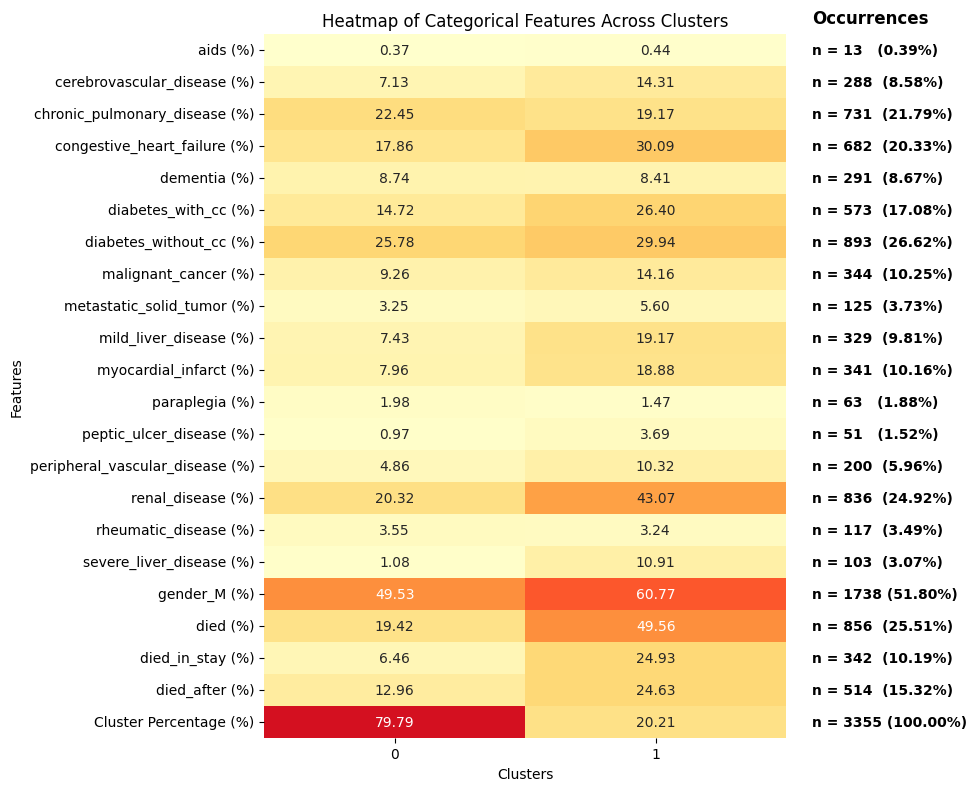

In [53]:
helper.clustering(
    n_clusters=ae_best_param["n_clusters"],
    affinity=ae_best_param["affinity"],
    n_neighbors=ae_best_param.get("n_neighbors", 10),
    gamma=ae_best_param.get("gamma", 1e-3),
    dimensionality_reduction={"method": "AE", "dimensions": 10},
)
helper.heatmapClustersCategorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    minimumClusterSize=2,
    savepath=IMAGES_SAVE_PATH + "spectral-dr-ae-categorical",
)

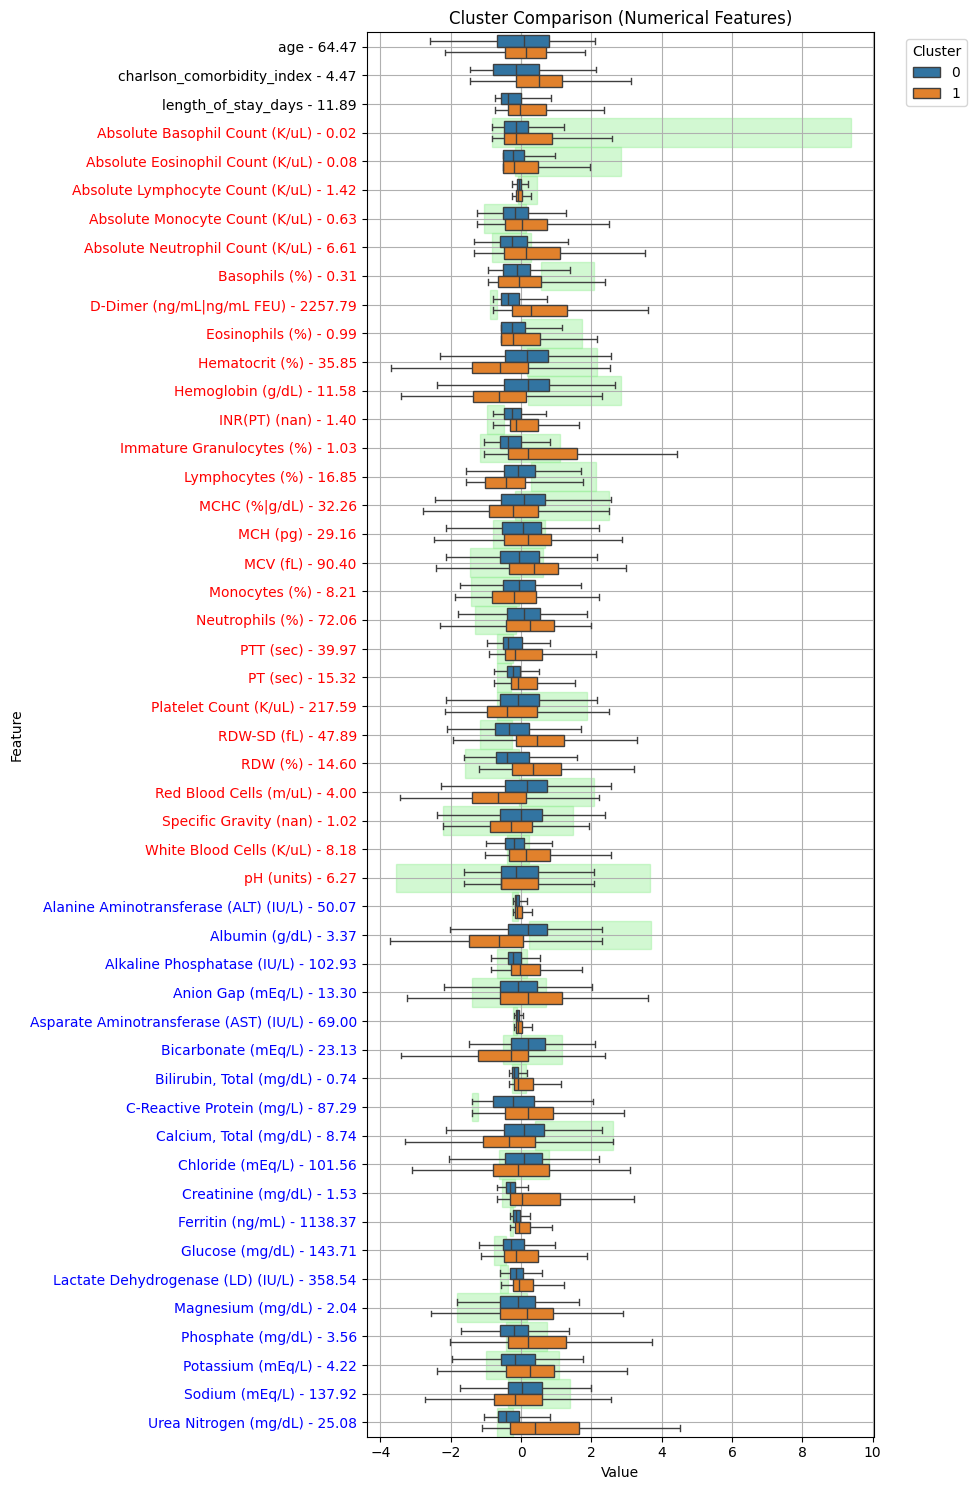

[]

In [54]:
helper.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=-1,
    figsize=(10, 15),
    byVariance=False,
    savepath=IMAGES_SAVE_PATH + "spectral-dr-ae-numerical",
    verbose=1,
)

In [55]:
selectedClusters = [0, 1]

In [56]:
helper.setClusteredAutoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:25<00:00,  3.94it/s]


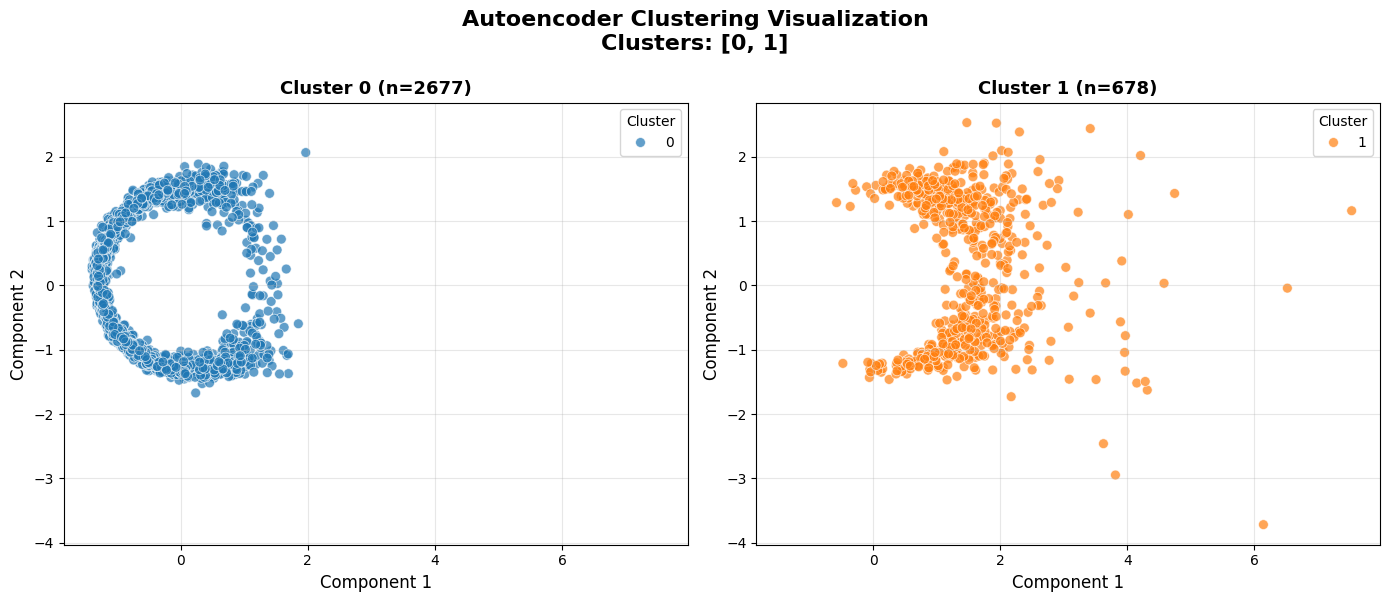

In [57]:
helper.showClusteredAutoencoder(selectedClusters=selectedClusters, savepath=IMAGES_SAVE_PATH + "spectral-autoencoder-dr-ae")

##### Future Data

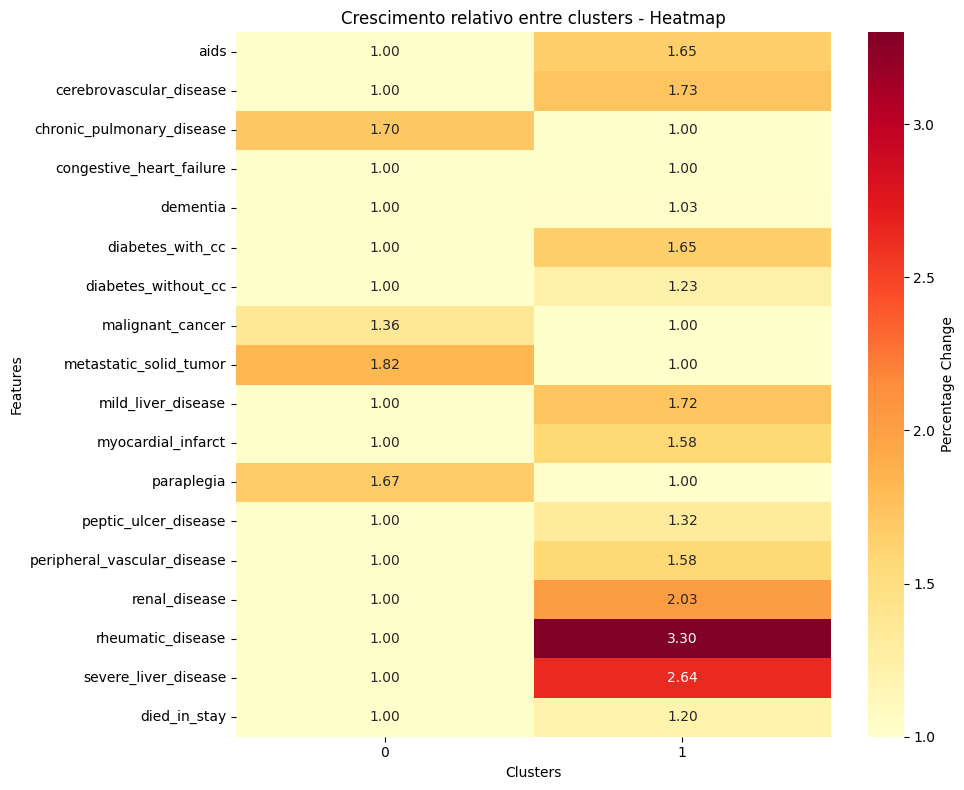

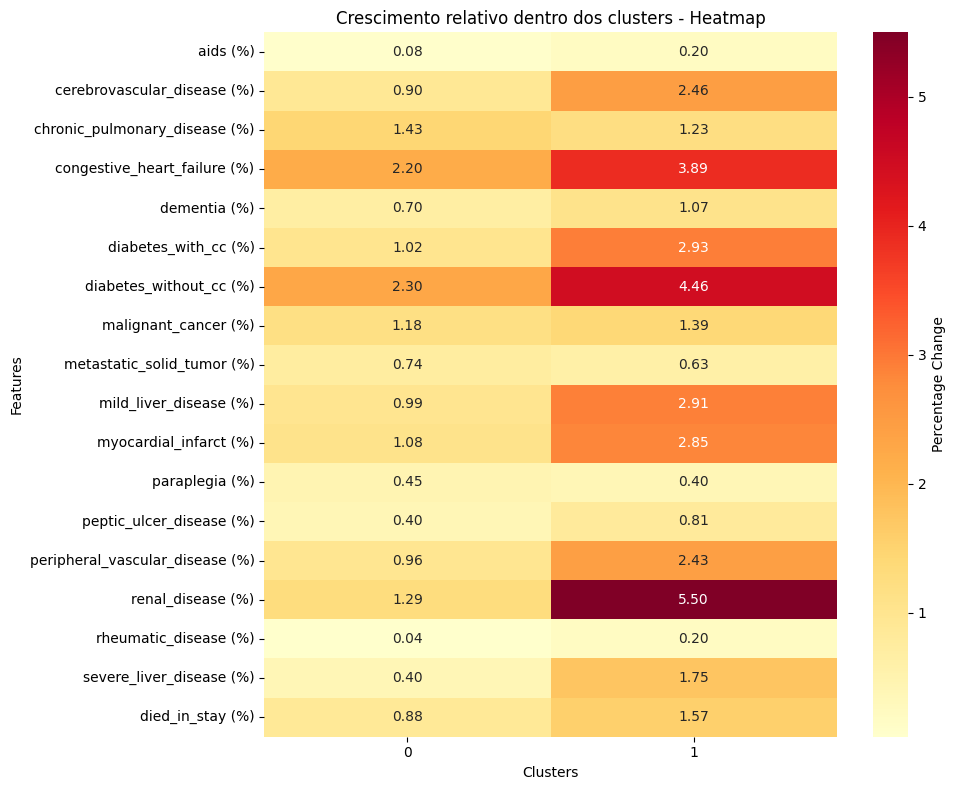

In [58]:
future_helper = fa.FutureAnalysisHelper(helper.clusteredData, future_data)
future_helper.insertClustersInFutureData(onlyFirstAdmission=True)
delta = future_helper.getDeltaClusters(percentage=True, metric="externo")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    selectedClusters=selectedClusters,
    savepath=IMAGES_SAVE_PATH + "spectral-dr-ae-externo",
    metric="externo"
)
delta = future_helper.getDeltaClusters(percentage=True, metric="interno")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    selectedClusters=selectedClusters,
    savepath=IMAGES_SAVE_PATH + "spectral-dr-ae-interno",
    metric="interno"
)

In [59]:
future_helper.getMeanReadmission()

{'Mean readmission Cluster 0': 2.23,
 'Mean readmission Cluster 1': 2.59,
 'Overall Mean readmission': 2.31}

In [60]:
future_helper.getMeanDaysGap()

{'Mean days gap Cluster 0': 130.38,
 'Mean days gap Cluster 1': 117.95,
 'Overall Mean days gap': 127.49}

In [61]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

{'Mortality rate Cluster 0': 0.13,
 'Mortality rate Cluster 1': 0.05,
 'Overall Mortality rate': 0.09}

### Add Log

In [62]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"Spectral,Autoencoder,Comprehensive,{metrics['disco']},{metrics['dbcv']},{metrics['dsi']},{metrics['silhouette']}\n")